<a href="https://colab.research.google.com/github/pelinbalci/graphrag_study/blob/main/leiden_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leiden Algorithm

In [1]:
pip install igraph leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.4 MB/s eta 0:00:00


In [19]:
import igraph as ig
import leidenalg

# 1. Create a graph
# Let's build a simple undirected graph
edges = [(0, 1), (1, 2), (2, 3), (0, 3),  # Cluster 1
         (4, 5), (5, 6), (6, 7), (4, 7),  # Cluster 2
         (0, 4)]  # A weak connection between the clusters

g = ig.Graph(edges=edges, directed=False)

# 2. Run the Leiden algorithm
partition = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition)

# 3. Print communities
for i, community in enumerate(partition):
    print(f"\nCommunity {i + 1}:")
    for node_id in community:
        print(f" - Node {node_id}: {edges[node_id]}")



Community 1:
 - Node 0: (0, 1)
 - Node 1: (1, 2)
 - Node 2: (2, 3)
 - Node 3: (0, 3)

Community 2:
 - Node 4: (4, 5)
 - Node 5: (5, 6)
 - Node 6: (6, 7)
 - Node 7: (4, 7)


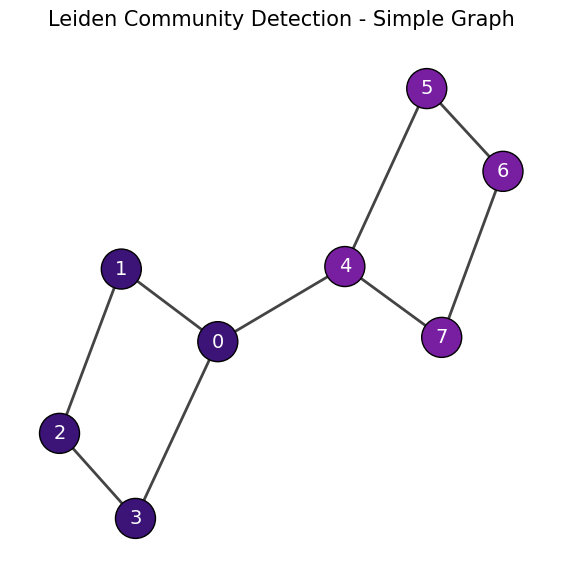

In [22]:
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ----------- First Example: Simple Graph Visualization -----------

# Assign node properties
g.vs["label"] = [str(i) for i in range(g.vcount())]
g.vs["color"] = [f"rgb({(c+1)*60}, {(c+2)*10}, {(c+3)*40})" for c in partition.membership]

# Plot
layout = g.layout("fr")
fig, ax = plt.subplots(figsize=(7, 7))
ig.plot(
    g,
    target=ax,
    layout=layout,
    vertex_size=40,
    vertex_color=g.vs["color"],
    vertex_label=g.vs["label"],
    vertex_label_size=14,
    vertex_label_color="white",
    edge_width=2,
)
plt.title("Leiden Community Detection - Simple Graph", fontsize=15)
plt.show()

🧠 What happened:

The graph has 8 nodes and two tightly connected clusters.

The algorithm discovered these two communities automatically.

It optimizes modularity, which rewards dense internal edges and sparse external ones.

# Leiden to Text


-> Cluster semantically similar documents using:

Sentence embeddings (via sentence-transformers)

Cosine similarity to build a graph

Leiden algorithm to find communities



In [3]:
pip install sentence-transformers scikit-learn igraph leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [18]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import igraph as ig
import leidenalg

# Step 1: Sample documents
documents = [
    "How to train a neural network.",
    "Deep learning and AI applications.",
    "Graph theory and community detection.",
    "Shortest path algorithms in graphs.",
    "Transformers in NLP.",
    "Self-attention in transformers.",
    "Breadth-first search and DFS."
]

# Step 2: Embed documents
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(documents)

# Step 3: Build similarity graph
cos_sim = cosine_similarity(embeddings)
threshold = 0.3  # Only connect nodes with similarity > 0.5

edges = []
weights = []

for i in range(len(cos_sim)):
    for j in range(i + 1, len(cos_sim)):
        if cos_sim[i][j] > threshold:
            edges.append((i, j))
            weights.append(cos_sim[i][j])

# Step 4: Create igraph graph
g2 = ig.Graph(edges=edges, directed=False)
g2.es['weight'] = weights

# Step 5: Run Leiden algorithm
partition2 = leidenalg.find_partition(g2, leidenalg.RBConfigurationVertexPartition, weights='weight')

# Step 6: Show results
for i, community in enumerate(partition2):
    print(f"\nCommunity {i + 1}:")
    for doc_id in community:
        print(f" - D{doc_id}: {documents[doc_id]}")



Community 1:
 - D0: How to train a neural network.
 - D1: Deep learning and AI applications.
 - D4: Transformers in NLP.
 - D5: Self-attention in transformers.

Community 2:
 - D2: Graph theory and community detection.
 - D3: Shortest path algorithms in graphs.
 - D6: Breadth-first search and DFS.


## Visualization

In [24]:
cos_sim.shape

(7, 7)

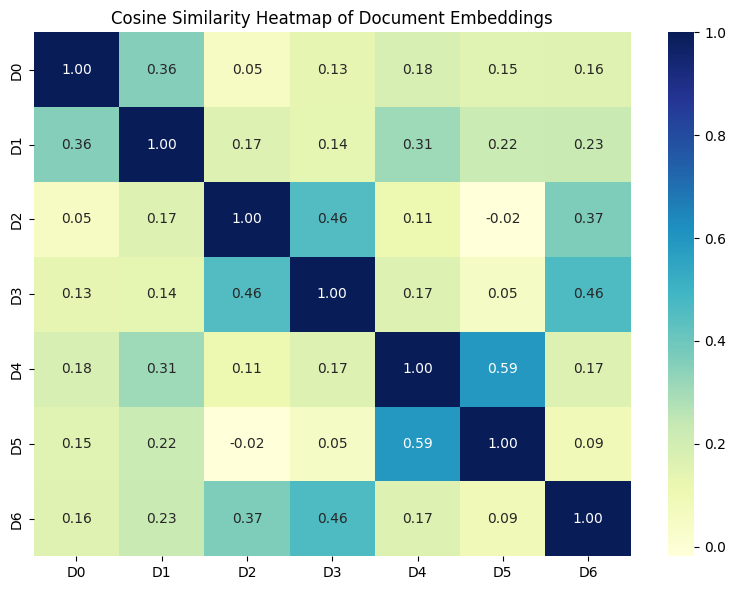

In [27]:
import pandas as pd
import seaborn as sns

# Step 3: Build heatmap
labels = [f"D{i}" for i in range(len(documents))]
df_sim = pd.DataFrame(cos_sim, index=labels, columns=labels)

# Step 4: Plot
plt.figure(figsize=(8, 6))
sns.heatmap(df_sim, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Cosine Similarity Heatmap of Document Embeddings")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


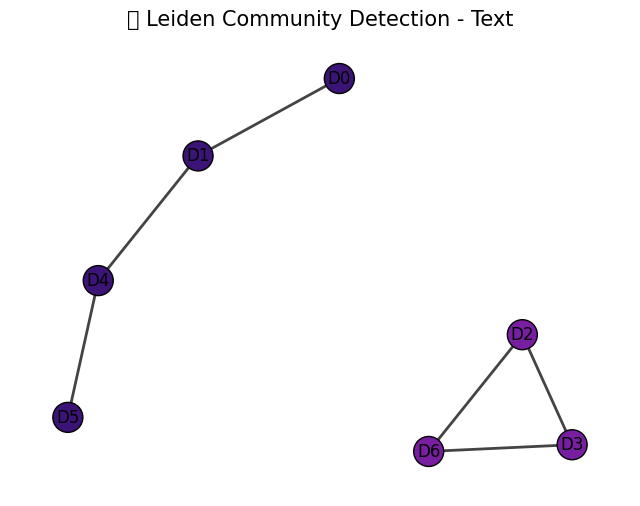

In [16]:

# ----------- Second Example: Document Graph Visualization -----------
# Assign document names and community colors
g2.vs["label"] = [f"D{i}" for i in range(len(documents))]
g2.vs["color"] = [f"rgb({(c+1)*60}, {(c+2)*10}, {(c+3)*40})" for c in partition2.membership]



layout2 = g2.layout("fr")

# Plot document graph
fig2, ax2 = plt.subplots(figsize=(8, 6))
ig.plot(g2, layout=layout2, target=ax2, vertex_size=30, edge_width=2.0, vertex_label=g2.vs["label"])

plt.title("🔍 Leiden Community Detection - Text", fontsize=15)
plt.show()
